In [1]:
pip install tensorflow keras matplotlib numpy scikit-learn

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
dataset=r"C:\Users\nagin\OneDrive\Desktop\galactic gazetter\archive\Planets_Moons_Data\Planets and Moons"

In [3]:
# Function to load images and preprocess them
def load_images(dataset, image_size):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset))
    class_indices = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(dataset, class_name)
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            if os.path.isfile(img_path):
                img = tf.keras.preprocessing.image.load_img(img_path, target_size=image_size)
                img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize
                images.append(img_array)
                labels.append(class_indices[class_name])

    return np.array(images), np.array(labels), class_names


In [4]:
# Define your dataset path
dataset_path = r"C:\Users\nagin\OneDrive\Desktop\galactic gazetter\archive\Planets_Moons_Data\Planets and Moons"

# Load images and get class names
image_size = (128, 128)
images, labels, class_names = load_images(dataset_path, image_size)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

class MyPyDataset(tf.data.Dataset):
    def __init__(self, *args, **kwargs):
        # Call the parent constructor
        super().__init__(activity_regularizer=activity_regularizer, **kwargs)
        #super().__init__(**kwargs)
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3), kernel_regularizer=regularizers.l2(0.01)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')  # Output layer for classification
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



C:\Users\nagin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)


In [6]:

# Data augmentation and fit model
datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2, horizontal_flip=True)
datagen.fit(X_train)

# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32), validation_data=(X_test, y_test), epochs=20)


C:\Users\nagin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.2057 - loss: 4.3670 - val_accuracy: 0.5335 - val_loss: 1.9378
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5068 - loss: 1.9874 - val_accuracy: 0.7165 - val_loss: 1.3148
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6231 - loss: 1.4950 - val_accuracy: 0.7348 - val_loss: 1.1664
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6417 - loss: 1.3806 - val_accuracy: 0.7957 - val_loss: 1.0468
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6940 - loss: 1.2404 - val_accuracy: 0.8659 - val_loss: 1.0063
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 911ms/step - accuracy: 0.7091 - loss: 1.1576 - val_accuracy: 0.6799 - val_loss: 1.1142
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 930ms/step - accuracy: 0.7072 - loss: 1.1204 - val_accuracy: 0.8049 - val_loss: 0.9389
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6879 - loss: 1.1577 - val_accuracy: 0.7713 - val

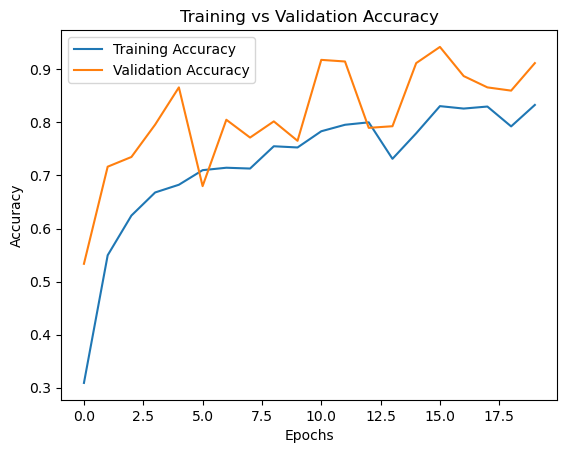

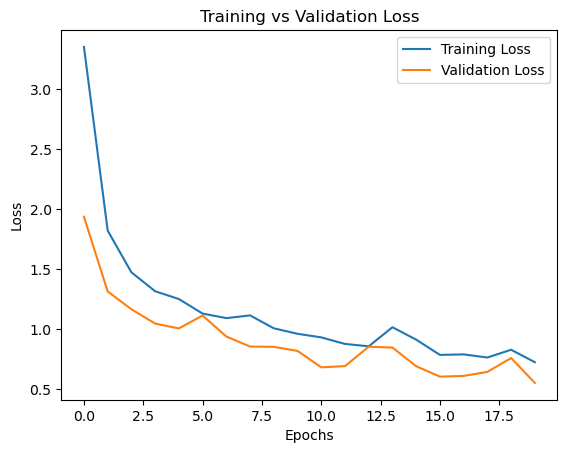

In [7]:
#edited
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()


In [8]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test accuracy
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.9142 - loss: 0.5379
Test Accuracy: 91.16%


In [9]:
test_loss, test_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 91.15%


In [15]:
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)

# Ensure that y_test is also integer encoded
# If you already encoded y_test, this part is not necessary
# If you haven't encoded y_test, encode it:
#y_test_encoded = label_encoder.transform(y_test)

# Get unique labels from both true and predicted labels
unique_labels = np.unique(np.concatenate((y_test, y_pred)))

# Filter target_names to match the unique labels
# Ensure that `class_names` is sorted in the same order as the labels.
filtered_target_names = [class_names[i] for i in unique_labels]

# Generate classification report with filtered target names
print(classification_report(y_test, y_pred, target_names=filtered_target_names))

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
              precision    recall  f1-score   support

       Earth       1.00      1.00      1.00        30
     Jupiter       0.97      1.00      0.98        31
    MakeMake       1.00      0.95      0.97        39
        Mars       0.95      1.00      0.97        37
     Mercury       0.56      1.00      0.72        33
        Moon       0.00      0.00      0.00        26
     Neptune       1.00      1.00      1.00        26
       Pluto       1.00      0.97      0.98        30
      Saturn       1.00      1.00      1.00        28
      Uranus       1.00      1.00      1.00        28
       Venus       1.00      1.00      1.00        20

    accuracy                           0.91       328
   macro avg       0.86      0.90      0.88       328
weighted avg       0.87      0.91      0.88       328



C:\Users\nagin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\nagin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\nagin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [10]:
model.save("planet_classifier.h5")

In [11]:
model = tf.keras.models.load_model('planet_classifier.h5')

In [18]:
#edited
# Function to predict the planet class from an image
def predict_planet(image_path, threshold=0.5):
    if not os.path.isfile(image_path):
        return "Error: File does not exist."

    valid_extensions = ['.jpg', '.jpeg', '.png']
    _, ext = os.path.splitext(image_path)
    if ext.lower() not in valid_extensions:
        return "Error: Invalid image file type."

    try:
        img = image.load_img(image_path, target_size=(128, 128))  # Load and resize the image
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make predictions
        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction[0])
        predicted_class_confidence = np.max(prediction[0])

        if predicted_class_confidence < threshold:
            return f"Unknown: Confidence {predicted_class_confidence:.2f} is below the threshold."

        return f"Predicted Class: {class_names[predicted_class_index]} (Confidence: {predicted_class_confidence:.2f})"

    except Exception as e:
        return f"Error during prediction: {str(e)}"


In [26]:
# Example of how to use the prediction function with a new image
image_path = r"D:\madhavi\archive\Planets_Moons_Data\Planets and Moons\MakeMake\Makemake (1).jpg"
result = predict_planet(image_path, threshold=0.5)
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Predicted Class: MakeMake (Confidence: 0.85)


In [20]:
pip install Flask

Note: you may need to restart the kernel to use updated packages.


In [21]:
from keras.applications.vgg16 import preprocess_input


In [22]:
from keras.applications.resnet50 import preprocess_input
